# Outlier থাকলেও ভালো কাজ করে

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.DataFrame({
    "h":[150,160,170,180,300],
    "w":[50,60,70,80,200]
})

df

,h,w
0,150,50
1,160,60
2,170,70
3,180,80
4,300,200


In [3]:
# step 1: median, quartiles, IQR
md=df.median()
q1=df.quantile(.25)
q3=df.quantile(.75)
iqr=q3-q1

md,q1,q3,iqr

(h    170.0
 w     70.0
 dtype: float64,
 h    160.0
 w     60.0
 Name: 0.25, dtype: float64,
 h    180.0
 w     80.0
 Name: 0.75, dtype: float64,
 h    20.0
 w    20.0
 dtype: float64)

In [5]:
# step 2: center by median
ct=df-md
ct

,h,w
0,-20.0,-20.0
1,-10.0,-10.0
2,0.0,0.0
3,10.0,10.0
4,130.0,130.0


In [6]:
# step 3: divide by IQR
rb=ct/iqr
rb.round(2)

,h,w
0,-1.0,-1.0
1,-0.5,-0.5
2,0.0,0.0
3,0.5,0.5
4,6.5,6.5


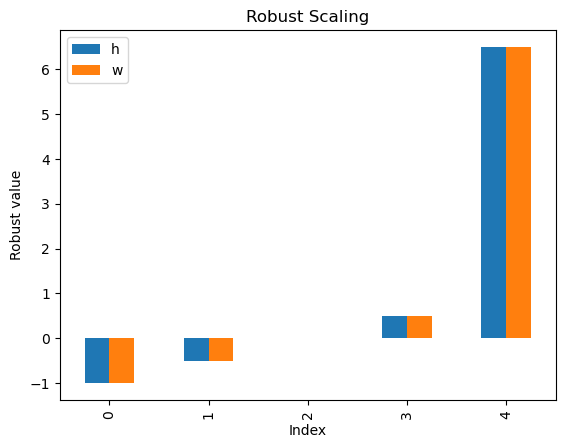

In [7]:
rb.plot(kind="bar")
plt.title("Robust Scaling")
plt.xlabel("Index")
plt.ylabel("Robust value")
plt.show()

In [9]:
# standarddization/z score
m=df.mean()
s=df.std()
z=(df-m)/s

# min max
mn=df.min()
mx=df.max()
mm=(df-mn)/(mx-mn)

#side-by-side

out=pd.concat([df,
               z.add_prefix("z_"),
               mm.add_prefix("mm_"),
               rb.add_prefix("rb_")],
               axis=1)

out.round(3)

,h,w,z_h,z_w,mm_h,mm_w,rb_h,rb_w
0,150,50,-0.684,-0.684,0.000,0.000,-1.0,-1.0
1,160,60,-0.521,-0.521,0.067,0.067,-0.5,-0.5
2,170,70,-0.358,-0.358,0.133,0.133,0.0,0.0
3,180,80,-0.195,-0.195,0.200,0.200,0.5,0.5
4,300,200,1.759,1.759,1.000,1.000,6.5,6.5
